# Hospital Readmission Prediction: Data Preparation

**Objective:** Load, audit, clean the dataset and perform univariate analysis before any modelling.

**Data source:** [Diabetes 130-US Hospitals (1999-2008)](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008), UCI Machine Learning Repository
**Stack:** Python, pandas, numpy, matplotlib, seaborn

---

**Steps covered in this notebook:**
1. Dataset Imports & Overview
2. Cleaning & Preprocessing
3. Univariate Analysis
4. Target Variable Engineering
5. Export: Cleaned Dataset


# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier 
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, roc_curve,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
PLOT_DIR = "../Plot"
os.makedirs(PLOT_DIR, exist_ok=True)
print("Libraries loaded successfully.")

Libraries loaded successfully.


# 1. Dataset Imports & Overview

**Question:** What does the raw dataset look like, and does it contain missing values?

**Context & Clinical Relevance:** Hospital administrative datasets are notoriously messy. Missing values in this dataset are disguised as `'?'` strings rather than standard Python `NaN`, a common pattern in exported EHR data that would silently corrupt downstream analyses if left untreated.

**Approach:** Two audit passes: a standard `isnull()` check, then a column-by-column scan for `'?'`. The top 3 most frequent values per column are also inspected to detect anomalies and understand the encoding scheme before cleaning.


In [2]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
"../data/diabetic_data_clean.csv"
df = pd.read_csv(r"F:\BD\hospital-readmission-project\data\diabetic_data.csv")

print(f"Dataset loaded: \n{df.shape[0]:,} patients | {df.shape[1]} variables")

print("\nFirst 5 rows:")
df.head()

DATASET OVERVIEW
Dataset loaded: 
101,766 patients | 50 variables

First 5 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# 2. Cleaning & Preprocessing

**Question:** How do we standardise missing value encoding and remove structurally unusable columns?

**Context & Clinical Relevance:** Columns where more than 60% of values are missing carry too little information to be usable; any analysis built on them would reflect absence of data more than clinical reality. Once these columns are removed, `'?'` placeholders are replaced with `NaN` so that pandas and scikit-learn handle missingness correctly.

**Approach:** A 60% threshold is applied for column removal, conservative enough to retain columns with partial missingness (which could be imputed later) while eliminating structurally empty fields. The `'Unknown/Invalid'` gender entries (3 cases, <0.01%) are treated as noise and set to `NaN`.

1. Replace `?` with proper `NaN`
2. Replace `'Unknown/Invalid'` with `NaN`
3. Drop columns with >60% disguised missing values (`?`)
4. Handle edge cases in categorical variables


## 2.1 Missing Values Audit


MISSING VALUES

--- Missing values audit ---
Total NaN before cleaning: 181168 | Total '?' before cleaning: 192849 | Total null: 374017

---Verification---
Total NaN After cleaning: 374017


,NaN_Count,Missing Rate (%)
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


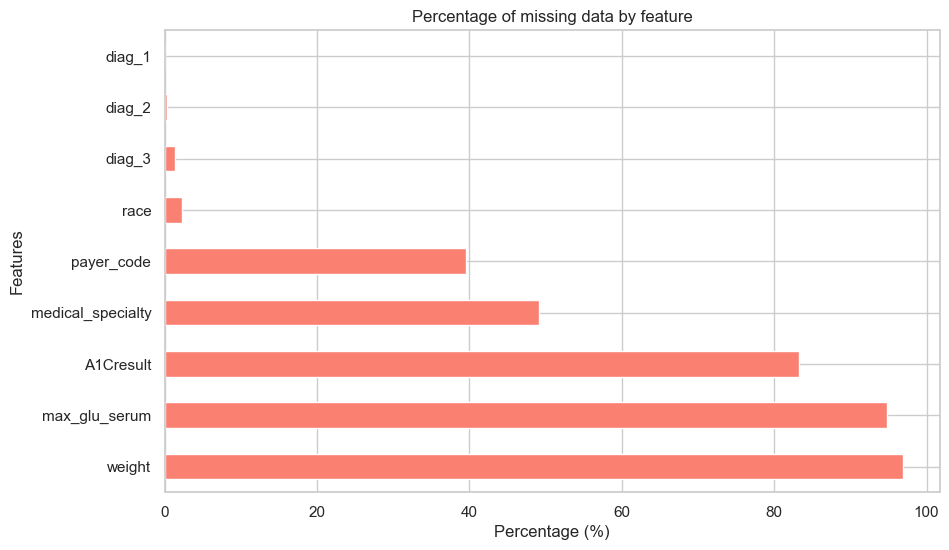


Plot successfully saved to: ../Plot\missing_data_audit.png


In [3]:
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)

print("\n--- Missing values audit ---")

total_question_marks = (df == '?').sum().sum()
total_nan_before = df.isna().sum().sum()
total_null = total_question_marks + total_nan_before

print(f"Total NaN before cleaning: {total_nan_before} | Total '?' before cleaning: {total_question_marks} | Total null: {total_null}")

# replace "?" by NaN
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)

print("\n---Verification---")

total_question_marks = (df == '?').sum().sum()
total_nan_before = df.isna().sum().sum()
total_null = total_question_marks + total_nan_before

print(f"Total NaN After cleaning: {total_nan_before}")

missing_rate = df.isna().mean() * 100

missing_data = pd.DataFrame({
    'NaN_Count': df.isnull().sum(),
    'Missing Rate (%)': missing_rate
})

missing_data = missing_data[missing_data["NaN_Count"] > 0]

missing_data = missing_data.sort_values(
    'Missing Rate (%)',
    ascending=False
)

display(missing_data)


plt.figure(figsize=(10, 6))
missing_data['Missing Rate (%)'].plot(kind='barh', color='salmon')
plt.title("Percentage of missing data by feature")
plt.xlabel("Percentage (%)")
plt.ylabel("Features")

save_path = os.path.join(PLOT_DIR, "missing_data_audit.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot successfully saved to: {save_path}")

**Results:** the audit finds 181,168 standard `NaN` and 192,849 disguised `'?'` values, 374,017 in total. Missingness is heavily concentrated in a handful of columns: `weight` (96.9%), `max_glu_serum` (94.7%) and `A1Cresult` (83.3%) are almost entirely empty, `medical_specialty` (49.1%) and `payer_code` (39.6%) are moderately incomplete, while `race`, `diag_2` and `diag_3` are missing in under 2.5% of rows. This confirms that a small set of columns drive the total missingness and are candidates for removal.


## 2.2 Missing Values Cleaning

In [4]:
cols_to_drop = missing_rate[missing_rate > 60].index.tolist()

print(f"\nColumns dropped (>60% missing): {cols_to_drop}")

df = df.drop(columns=cols_to_drop)

total_nan = df.isnull().sum().sum()
print(f"\nCleaning complete. Total NaN values after cleaning: {total_nan:,}")
print(f"\nRemaining columns: {df.shape[1]}")


Columns dropped (>60% missing): ['weight', 'max_glu_serum', 'A1Cresult']

Cleaning complete. Total NaN values after cleaning: 94,280

Remaining columns: 47


**Results:** applying the 60% threshold drops `weight`, `max_glu_serum` and `A1Cresult`, leaving 47 columns and 94,280 remaining `NaN` values (mostly in `medical_specialty` and `payer_code`, which fall below the threshold and are kept for later imputation or encoding).


# 3. Univariate Analysis

**Question:** What are the distributions of the key variables that will form the clinical dimensions?

**Context & Clinical Relevance:** Inspecting individual variable distributions before modelling reveals skewness, zero-inflation, and outliers that could bias composite scores. `number_inpatient`, `number_emergency` and `number_outpatient` are expected to be highly zero-inflated (most patients have no prior acute episode), while variables like `num_lab_procedures` are expected to follow a roughly normal distribution. These patterns justify the use of `MinMaxScaler` rather than `StandardScaler` in the feature engineering phase.

**Approach:** Descriptive statistics (mean, std, quartiles, skewness, median) and histograms with KDE for all 7 variables used in the 3 clinical dimensions.


## 3.1 Quantitative Analysis

In [5]:
print(df.columns)

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted'],
      dtype='object')



QUANTITATIVES ANALYSIS
                       count   mean    std  min   25%   50%   75%    max
time_in_hospital    101766.0   4.40   2.99  1.0   2.0   4.0   6.0   14.0
num_lab_procedures  101766.0  43.10  19.67  1.0  31.0  44.0  57.0  132.0
num_procedures      101766.0   1.34   1.71  0.0   0.0   1.0   2.0    6.0
num_medications     101766.0  16.02   8.13  1.0  10.0  15.0  20.0   81.0
number_outpatient   101766.0   0.37   1.27  0.0   0.0   0.0   0.0   42.0
number_emergency    101766.0   0.20   0.93  0.0   0.0   0.0   0.0   76.0
number_inpatient    101766.0   0.64   1.26  0.0   0.0   0.0   1.0   21.0
number_diagnoses    101766.0   7.42   1.93  1.0   6.0   8.0   9.0   16.0


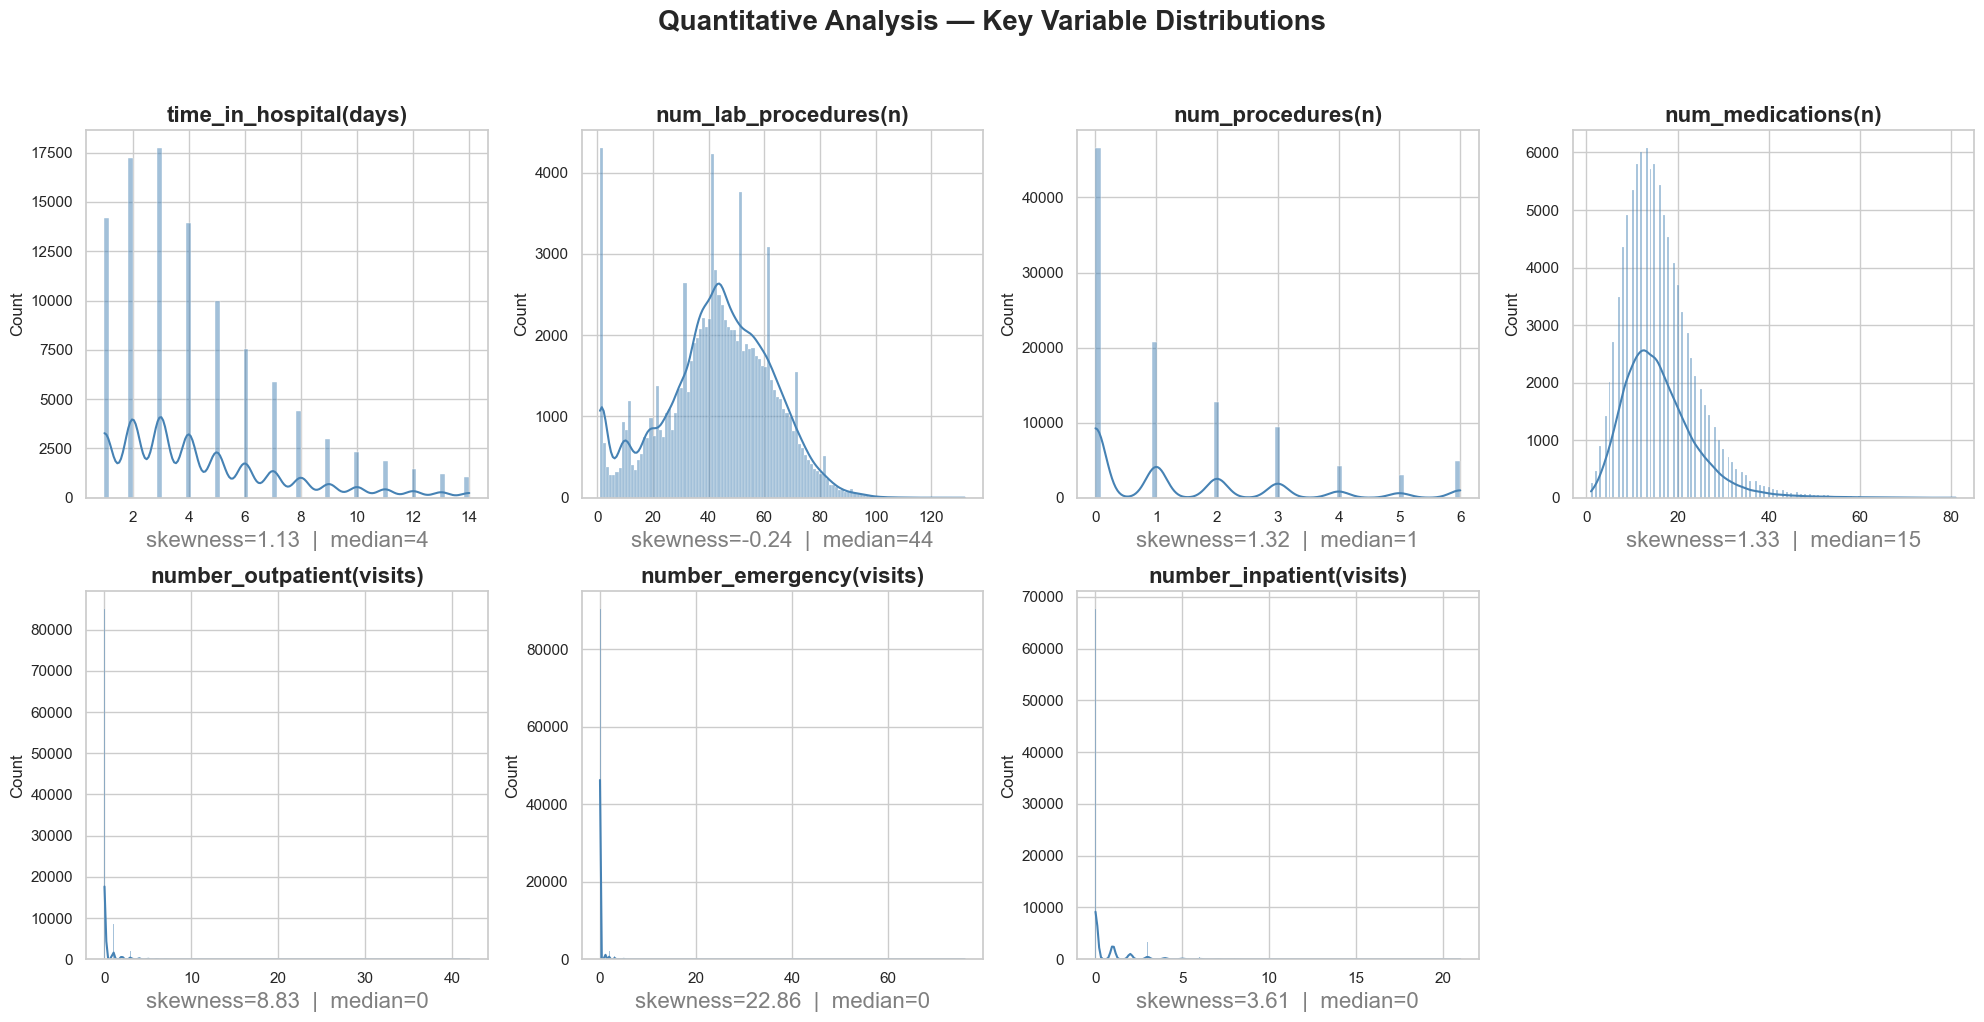

In [6]:
print("\n" + "="*50)
print("QUANTITATIVES ANALYSIS")
print("="*50)

key_vars = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_outpatient', 'number_emergency', 
            'number_inpatient', 'number_diagnoses'
]

units = {
    'time_in_hospital': 'days',
    'num_lab_procedures': 'n',
    'num_procedures': 'n',
    'num_medications': 'n',
    'number_outpatient': 'visits',
    'number_emergency': 'visits',
    'number_inpatient': 'visits',
    'number_diagnoses': 'n'
}

print(df[key_vars].describe().T.round(2))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_vars):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i],
                 color='steelblue', edgecolor='white')
    skew   = df[col].skew()
    median = df[col].median()
    axes[i].set_title(f"{col}({units.get(col, '')})", fontsize=16, fontweight='bold')
    axes[i].set_xlabel(f'skewness={skew:.2f}  |  median={median:.0f}',
                       fontsize=16, color='gray')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Quantitative Analysis — Key Variable Distributions',
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig(os.path.join(PLOT_DIR, "univariate_distributions.png"), dpi=150, bbox_inches='tight')
plt.show()

**Results:** `time_in_hospital` averages 4.4 days (median 4, range 1-14), and `num_lab_procedures` averages 43 (SD 19.7), both reasonably close to normal. `num_medications` (mean 16, SD 8.1) and `num_procedures` (mean 1.3, SD 1.7) are right-skewed. As expected, `number_inpatient`, `number_emergency` and `number_outpatient` are strongly zero-inflated: most patients have no prior acute episode, with a long tail of high utilisers. This confirms the choice of `MinMaxScaler` over `StandardScaler`, since these distributions are far from Gaussian.


## 3.2 Qualitative Analysis


QUALITATIVES ANALYSIS


,count,mean,std,min,25%,50%,75%,max
admission_type_id,101766.0,2.02,1.45,1.0,1.0,1.0,3.0,8.0


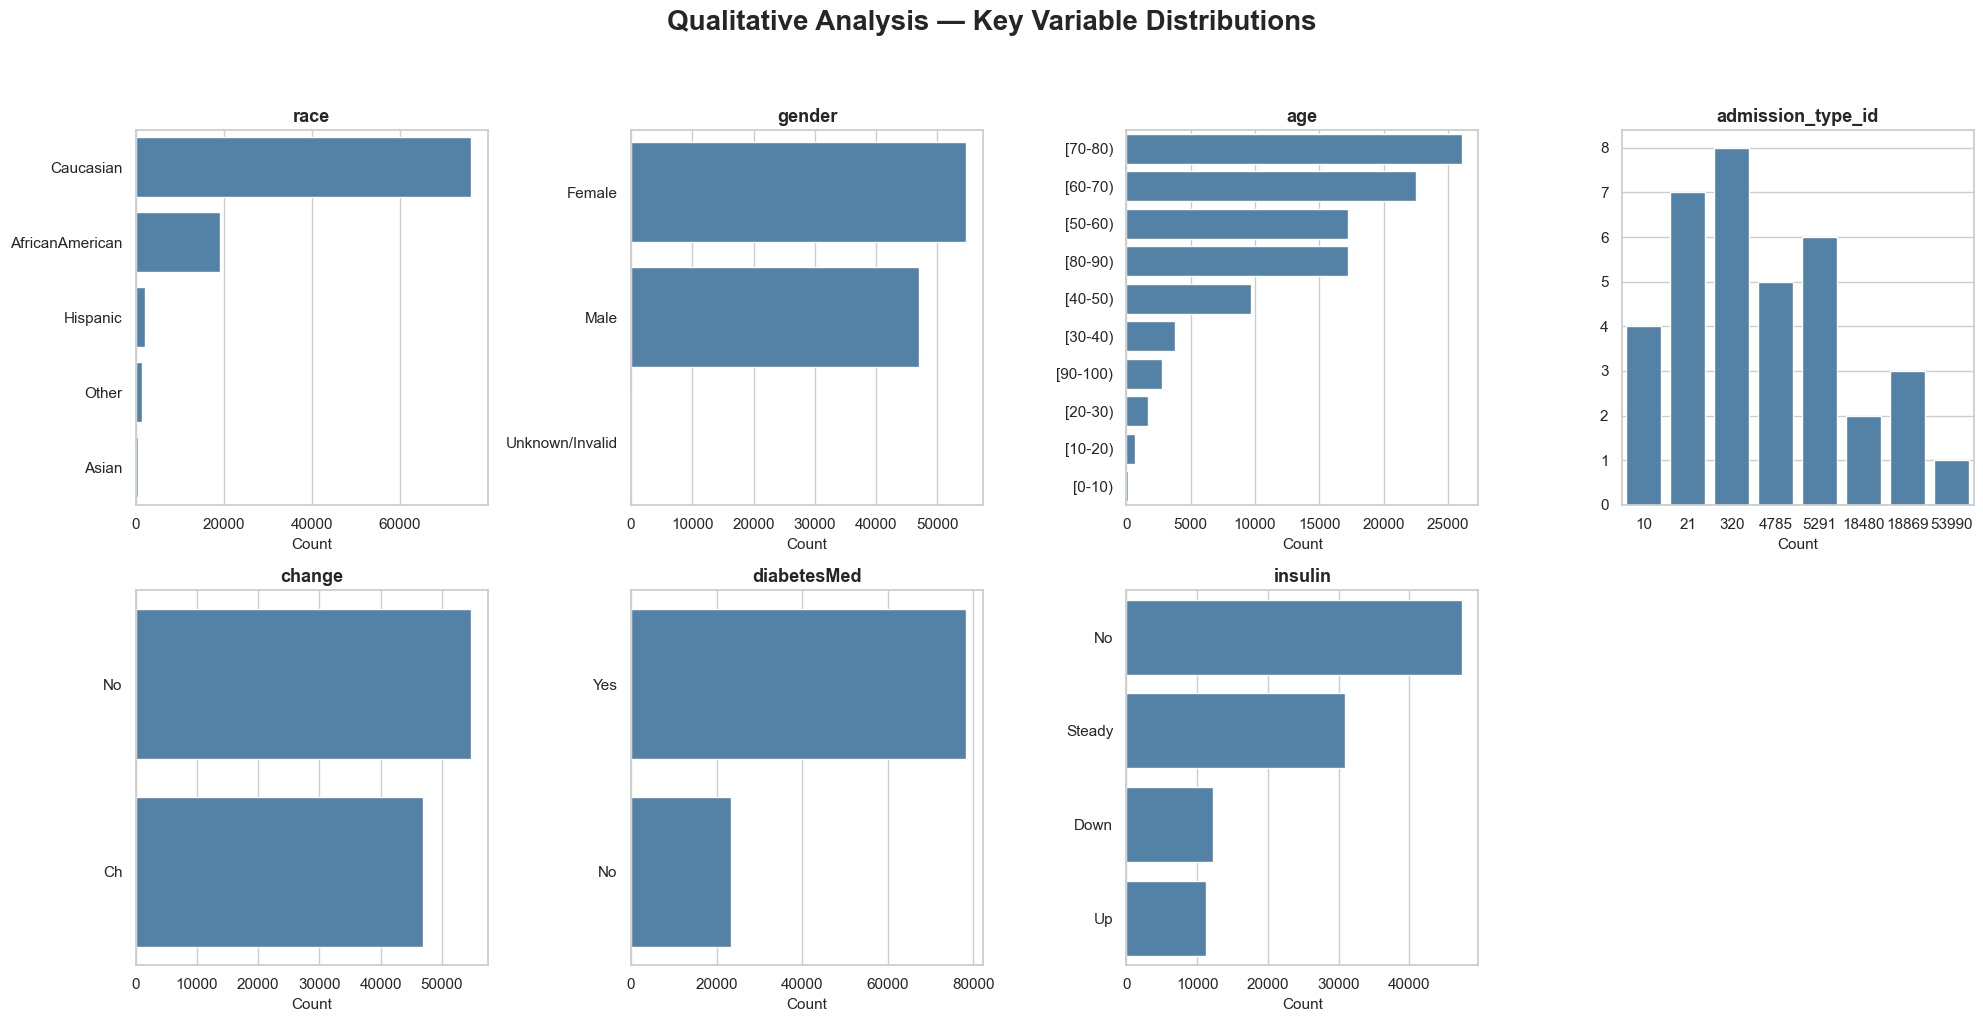

In [7]:
print("\n" + "="*50)
print("QUALITATIVES ANALYSIS")
print("="*50)

qual_vars = ['race', 'gender', 'age', 'admission_type_id', 'change',
             'diabetesMed', 'insulin']

display(df[qual_vars].describe().T.round(2))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(qual_vars):
    top_cats = df[col].value_counts().head(10)
    sns.barplot(x=top_cats.values, y=top_cats.index,
                ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Count', fontsize=11)
    axes[i].set_ylabel('')

for j in range(len(qual_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Qualitative Analysis — Key Variable Distributions',
             fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig(os.path.join(PLOT_DIR, "univariate_qualitative.png"), dpi=150, bbox_inches='tight')
plt.show()

**Results:** the qualitative variables show the expected clinical patterns, e.g. `admission_type_id` is concentrated around emergency/urgent codes (mean 2.0, most values between 1 and 3). No unexpected categories are found beyond the `'Unknown/Invalid'` gender entries already handled in the cleaning step.


# 4. Target Variable Engineering

**Question:** How do we define hospital readmission as a binary prediction target?

**Context & Clinical Relevance:** The original target variable `readmitted` is a three-class outcome: `'NO'`, `'<30'`, and `'>30'`, representing no readmission, readmission within 30 days, and readmission after 30 days respectively. In a clinical risk prediction setting, the primary objective is to identify patients at risk of future readmission prior to discharge. Both early and late readmissions represent a failure of care continuity, although early readmission (<30 days) is more commonly used as a proxy for quality of care.

**Approach:** The target is redefined as a binary outcome:
- `1` = readmitted (either <30 days or >30 days)
- `0` = not readmitted

This lets the model focus on predicting the occurrence of any readmission event rather than its timing. A multiclass or survival analysis formulation could give more granular insight into readmission timing, but this is left out of scope for this initial modelling phase.


In [8]:
df['is_readmitted'] = (df['readmitted'] != 'NO').astype(int)

dist = df['is_readmitted'].value_counts()
pct = df['is_readmitted'].value_counts(normalize=True) * 100

print("=== Target variable distribution ===")
for i in [0, 1]:
    print(f"{i} : {dist.get(i, 0):,} ({pct.get(i, 0):.1f}%)")

imbalance = pct[0] / pct[1] if pct[1] != 0 else None
print(f"\nImbalance ratio: {imbalance:.1f}:1")


=== Target variable distribution ===
0 : 54,864 (53.9%)
1 : 46,902 (46.1%)

Imbalance ratio: 1.2:1


**Results:** 54,864 patients (53.9%) are not readmitted and 46,902 (46.1%) are readmitted (either <30 or >30 days), an imbalance ratio of 1.2:1. This is a moderate imbalance, not severe enough to require resampling, but enough to justify `class_weight='balanced'` in the classifier trained later.


# Export - Cleaned Dataset

In [9]:
df.to_csv("../data/diabetic_data_clean.csv", index=False)
path = "../data/diabetic_data_clean.csv"
print("File exists:", os.path.exists(path))

File exists: True


## Summary

| Step | Action | Result |
|------|--------|--------|
| Audit | Detected `'?'` as missing placeholder | 374,017 missing values total (181,168 NaN + 192,849 `'?'`) |
| Harmonisation | Replaced `'?'` with `NaN` | n/a |
| Cleaning | Dropped columns with >60% missing | `weight` (96.9%), `max_glu_serum` (94.7%), `A1Cresult` (83.3%) |
| Target | Binarised `readmitted` | 54,864 not readmitted (53.9%) / 46,902 readmitted (46.1%), imbalance ratio 1.2:1 |

**Next step:** `02_feature_engineering.ipynb`, correlation analysis and construction of the 3 clinical dimensions.
